# Map back Alveolar Epithelium annotations to the combined object

Imports

In [1]:
# %% Libraries

import os
import scanpy as sc
import numpy as np
from pathlib import Path
import rapids_singlecell as rsc
import pandas as pd
from scipy.sparse import issparse

# %% Setting Paths
MAIN_DIR_NAME = "proseg_data"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(SEED_VALUE)

# %% object versions
COMB_V= 'refined-clustered'
COMB_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-{COMB_V}.h5ad'


SUB_OBJ = "alveolar-epithelium"
SUB_OBJ_V = 'reclustered'
SUB_OBJ_PATH = MAIN_DIR / 'data' / 'sub' / SUB_OBJ / 'h5ad' / f'{SUB_OBJ}-{SUB_OBJ_V}.h5ad'

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load comb obj
comb = sc.read_h5ad(COMB_PATH)

In [10]:
# load airway epi obj
sub = sc.read_h5ad(SUB_OBJ_PATH)

Get all the cell names and annotations

In [11]:
sub_ann = sub.obs[["leiden","reclustered_ct"]].copy()

In [12]:
## SET COLUMN NAME ##

# Define clustering parameters used to construct the column name
NN = 10
SUB_RES = 0.5
COL_NAME = f"{SUB_OBJ}_leiden_n{NN}_{SUB_RES}"


# Rename the subclustering columns before mapping them back to comb.obs
sub_ann = sub_ann.rename(columns={
    "leiden": COL_NAME,
    "reclustered_ct": "ann_lvl_3_refined",
})


## MAP RESULTS BACK TO FULL OBJECT ##

# Map airway epithelial Leiden clusters back to comb.obs.
# Cells not present in sub_ann will remain NaN.
comb.obs[COL_NAME] = (
    sub_ann[COL_NAME]
    .reindex(comb.obs.index)
)

# Start with the previous annotation for every cell
comb.obs["ann_lvl_3_refined"] = comb.obs["ann_lvl_3_refined"].astype(str)

# Identify cells shared between the full object and the airway epithelial subset
common_cells = comb.obs.index.intersection(sub_ann.index)

# Replace annotations only for cells that were included in the airway
# epithelial subclustering.
comb.obs.loc[common_cells, "ann_lvl_3_refined"] = (
    sub_ann.loc[common_cells, "ann_lvl_3_refined"].astype(str)
)

## EXAMINE METADATA ##

comb.obs[[COL_NAME,'ann_lvl_3_refined']]

,alveolar-epithelium_leiden_n10_0.5,ann_lvl_3_refined
cell_id,,
SLIDE04_0,NaN,PC_K_IgA
SLIDE04_2,NaN,Fib
SLIDE04_3,NaN,Neut
SLIDE04_4,NaN,CD8_T
SLIDE04_5,NaN,Fib
...,...,...
SLIDE02_426982,NaN,EC
SLIDE02_426983,NaN,EC
SLIDE02_426985,NaN,Amb


In [13]:
# Check the values from COL_NAME
comb.obs[COL_NAME].value_counts(dropna=False)

alveolar-epithelium_leiden_n10_0.5
NaN    1074662
3        29423
2        24726
0        23580
1        16520
4        12595
5         4717
6         1118
Name: count, dtype: int64

### View in UMAP

... storing 'ann_lvl_3_refined' as categorical


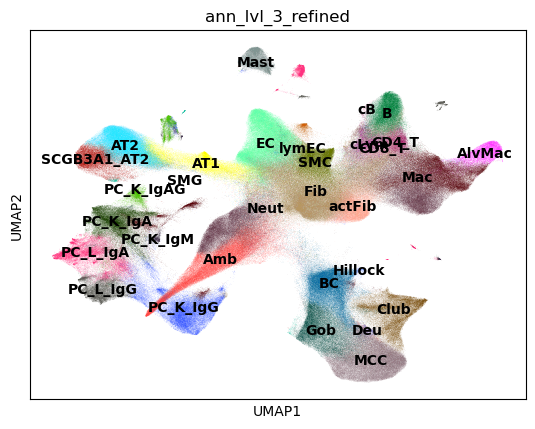

In [14]:
sc.pl.umap(
    comb, 
    color=["ann_lvl_3_refined"],
    legend_loc="on data"
)

Save the annotated object

In [16]:
comb.write_h5ad(COMB_PATH)

In [17]:
# check number of cell types 
comb.obs['ann_lvl_3_refined'].unique()

['PC_K_IgA', 'Fib', 'Neut', 'CD8_T', 'SMC', ..., 'MCC', 'cB', 'Hillock', 'SMG', 'Deu']
Length: 31
Categories (31, object): ['AT1', 'AT2', 'AlvMac', 'Amb', ..., 'actFib', 'cB', 'cLym', 'lymEC']